# Spectral Calibration Framework

This notebook implements the common-field spectral calibration framework described in `docs/main.tex`.

**System boundary**
- Domain/core: latent-spectrum estimation, smooth gain/noise recovery, deployment correction, and consensus fusion.
- Application/orchestration: dataset loading, deterministic hold-out validation, plotting, and summary tables.
- Side effects: reading CSV files and rendering figures only.
- Pattern choice: the notebook stays thin and delegates the reusable estimation logic to `measurement_calibration.spectral_calibration`, which keeps the numerical core testable.

**Pragmatic simplifications kept explicit**
- The sensor update uses a nonnegative affine fit `Y = G S + N` at each frequency.
- Frequency smoothness is enforced with second-difference Tikhonov regularization, matching the penalized objective in the document.
- Sensor 7 is a soft anchor through regularization and a mild reliability weight boost, never a hard perfect-reference constraint.

In [9]:
# ruff: noqa: E402
from __future__ import annotations

from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from measurement_calibration import (
    apply_deployed_calibration,
    compute_network_consensus,
    fit_spectral_calibration,
    load_calibration_dataset,
    make_holdout_split,
    power_linear_to_db,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.3f}".format

DATA_ROOT = REPO_ROOT / "data"
AQUISITION_DIR = DATA_ROOT / "aquisitions"
RESPONSE_DIR = DATA_ROOT / "frequency-responses"

## Load And Align The Common-Field Dataset

The raw acquisition files are not perfectly rectangular:

- `Node10-Bogota` starts one experiment later than the main sequence.
- `Node9-Funza` contains one initial scan in a different band (`137-157 MHz`) before switching to the shared `88-108 MHz` band.
- `Node8-Bogota` is the shortest file, so it determines the final common experiment count.

The loader keeps only the band shared by all sensors and uses small integer index shifts relative to `Node1-Bogota` to build the admissible calibration tensor required by the model assumptions.

In [10]:
dataset = load_calibration_dataset(
    acquisition_dir=AQUISITION_DIR,
    response_dir=RESPONSE_DIR,
    reference_sensor_id="Node7-Bogota",
)

alignment_summary = pd.DataFrame(
    {
        "sensor_id": dataset.sensor_ids,
        "shift_vs_node7": [
            dataset.sensor_shifts[sensor_id] for sensor_id in dataset.sensor_ids
        ],
        "median_alignment_error_ms": [
            dataset.alignment_median_error_ms[sensor_id]
            for sensor_id in dataset.sensor_ids
        ],
        "selected_rows": [
            int(dataset.source_row_indices[sensor_id].size)
            for sensor_id in dataset.sensor_ids
        ],
        "nominal_gain_center_db": power_linear_to_db(
            dataset.nominal_gain_power[:, dataset.nominal_gain_power.shape[1] // 2]
        ),
    }
)

display(alignment_summary)
print(
    f"Selected common band: {dataset.selected_band_hz[0] / 1e6:.1f}-{dataset.selected_band_hz[1] / 1e6:.1f} MHz"
)
print(
    f"Observation tensor shape: {dataset.observations_power.shape} = (sensors, experiments, frequencies)"
)
print(
    f"Frequency resolution: {(dataset.frequency_hz[1] - dataset.frequency_hz[0]):.3f} Hz per bin"
)

,sensor_id,shift_vs_node7,median_alignment_error_ms,selected_rows,nominal_gain_center_db
0,Node1-Bogota,0,2029.000,22,-1.150
1,Node10-Bogota,-1,356.500,22,4.582
2,Node2-Bogota,0,1982.000,22,6.728
3,Node3-Bogota,0,2127.000,22,0.940
4,Node4-Bogota,0,227.000,22,-4.894
5,Node5-Bogota,0,414.000,22,0.389
6,Node6-Bogota,0,2151.000,22,1.772
7,Node7-Bogota,0,0.000,22,6.143
8,Node8-Bogota,0,2128.000,22,6.428
9,Node9-Funza,-1,17492.500,22,-20.938


Selected common band: 88.0-108.0 MHz
Observation tensor shape: (10, 22, 32768) = (sensors, experiments, frequencies)
Frequency resolution: 610.352 Hz per bin


## Fit The Alternating Latent-Variable Model

We keep the final 20% of aligned experiments as a strict hold-out set, which mirrors the validation principle in `docs/main.tex`: parameters are estimated on common-field training experiments and evaluated on unseen common-field experiments after deployment-time correction.

The fitting cell below uses the nominal response curves as multiplicative baselines, then estimates a smooth residual correction around them.

In [11]:
train_indices, test_indices = make_holdout_split(
    n_experiments=dataset.observations_power.shape[1],
    test_fraction=0.2,
)

fit_config = {
    "n_iterations": 8,
    "lambda_gain_smooth": 50.0,
    "lambda_noise_smooth": 20.0,
    "lambda_reliable_anchor": 0.5,
    "reliable_weight_boost": 1.10,
}

start_time = time.perf_counter()
result = fit_spectral_calibration(
    observations_power=dataset.observations_power,
    frequency_hz=dataset.frequency_hz,
    sensor_ids=dataset.sensor_ids,
    nominal_gain_power=dataset.nominal_gain_power,
    train_indices=train_indices,
    test_indices=test_indices,
    reliable_sensor_id="Node7-Bogota",
    **fit_config,
)
fit_duration_s = time.perf_counter() - start_time

fit_summary = pd.DataFrame(
    {
        "parameter": [
            "train_experiments",
            "test_experiments",
            "iterations",
            "fit_duration_s",
            "objective_start",
            "objective_end",
        ],
        "value": [
            int(train_indices.size),
            int(test_indices.size),
            fit_config["n_iterations"],
            fit_duration_s,
            float(result.objective_history[0]),
            float(result.objective_history[-1]),
        ],
    }
)

display(fit_summary)

,parameter,value
0,train_experiments,18.000
1,test_experiments,4.000
2,iterations,8.000
3,fit_duration_s,5.631
4,objective_start,-37269531.768
5,objective_end,-39214172.171


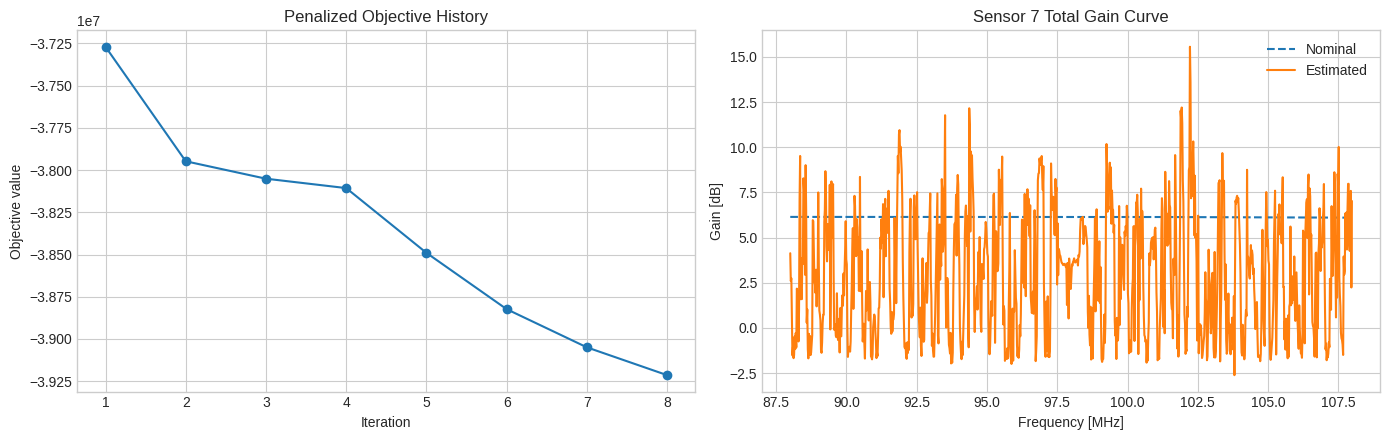

In [12]:
plot_stride = max(1, dataset.frequency_hz.size // 1024)
freq_mhz = dataset.frequency_hz[::plot_stride] / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(
    np.arange(1, result.objective_history.size + 1),
    result.objective_history,
    marker="o",
)
axes[0].set_title("Penalized Objective History")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Objective value")

reliable_sensor_index = dataset.sensor_ids.index("Node7-Bogota")
axes[1].plot(
    freq_mhz,
    power_linear_to_db(result.nominal_gain_power[reliable_sensor_index, ::plot_stride]),
    linestyle="--",
    label="Nominal",
)
axes[1].plot(
    freq_mhz,
    power_linear_to_db(result.gain_power[reliable_sensor_index, ::plot_stride]),
    label="Estimated",
)
axes[1].set_title("Sensor 7 Total Gain Curve")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("Gain [dB]")
axes[1].legend()
plt.tight_layout()

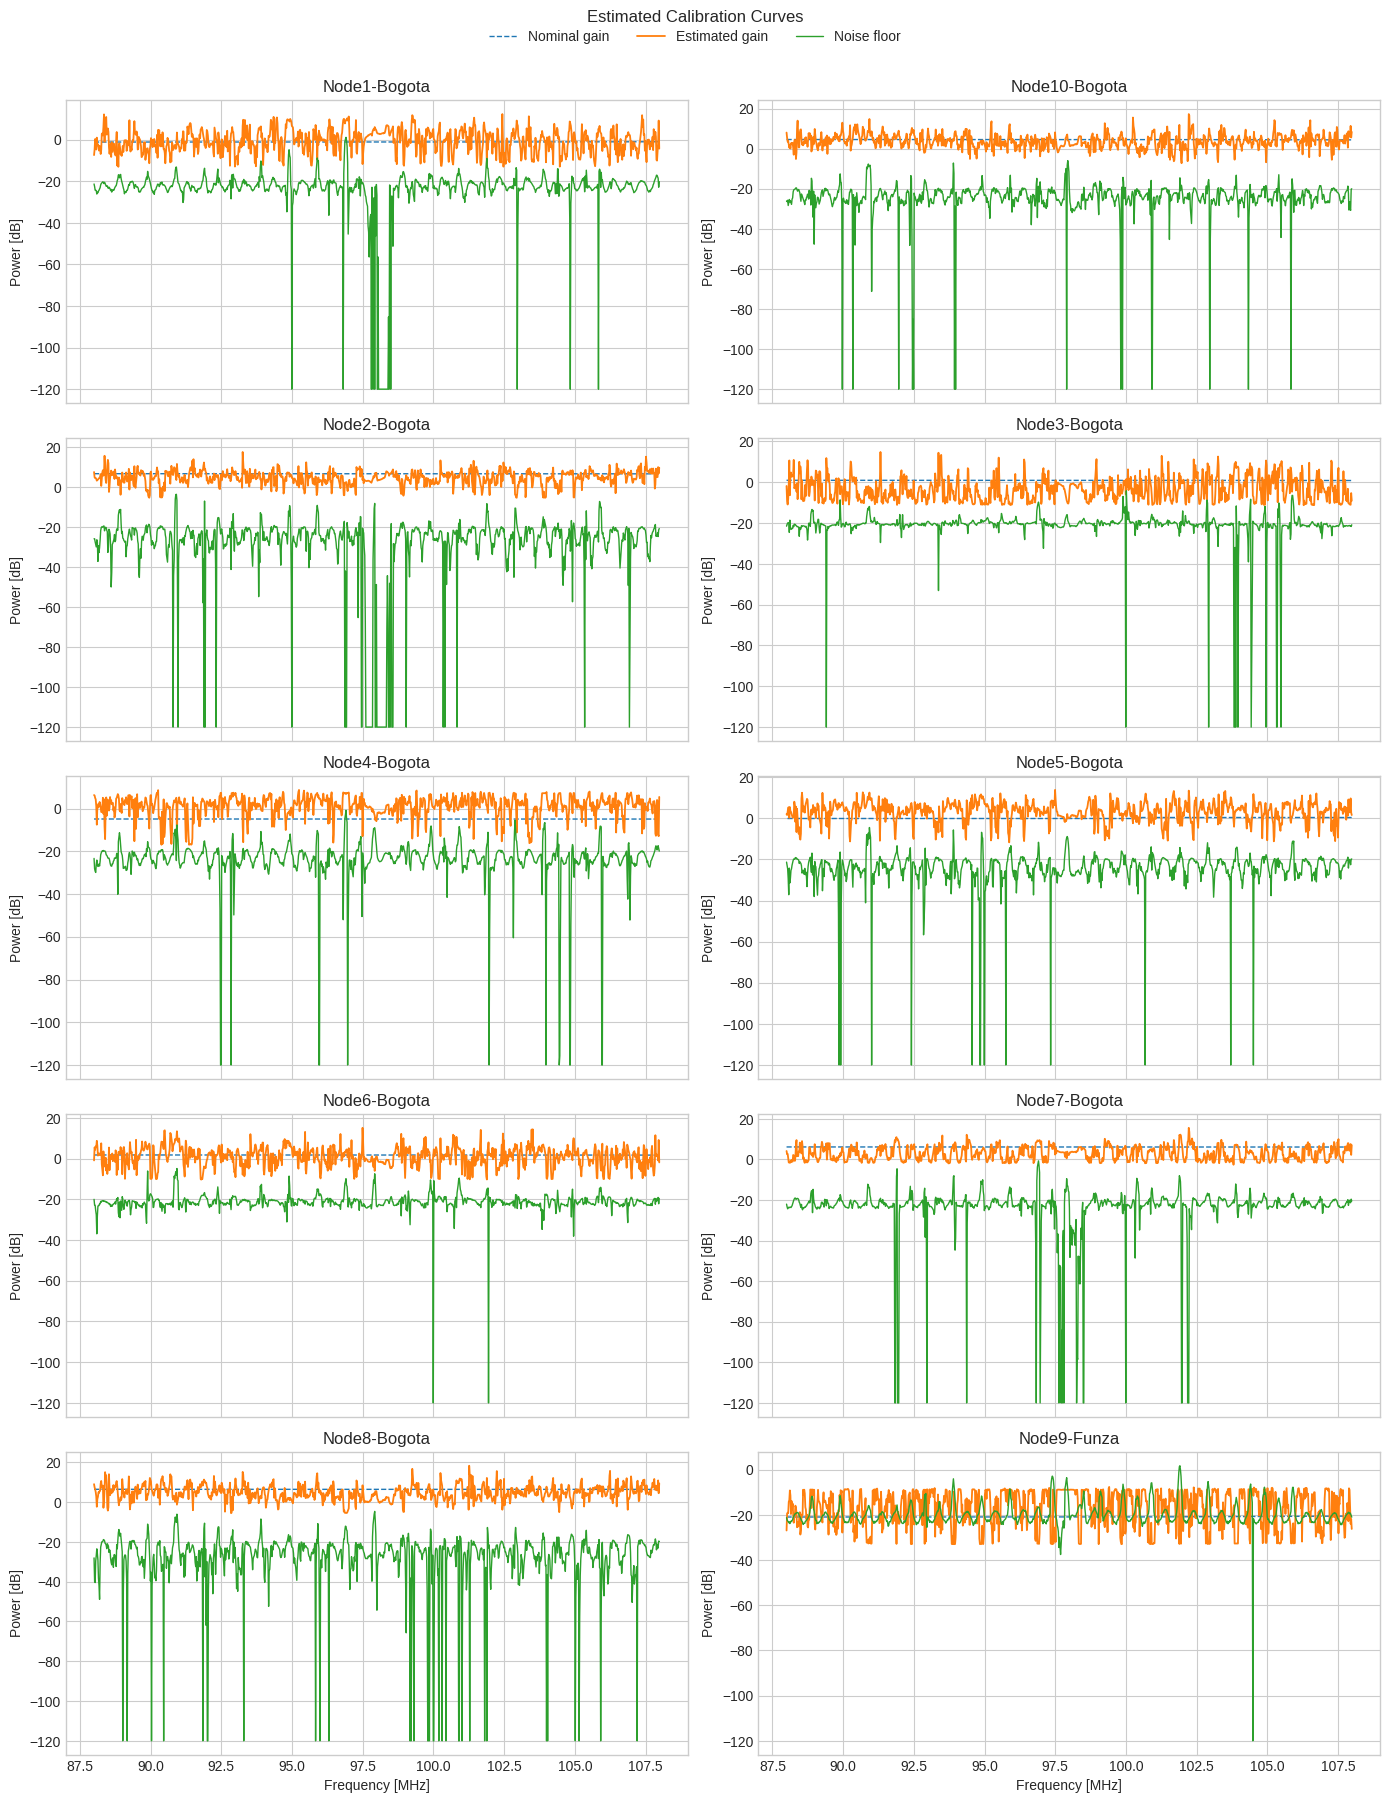

In [13]:
estimated_gain_db = power_linear_to_db(result.gain_power[:, ::plot_stride])
nominal_gain_db = power_linear_to_db(result.nominal_gain_power[:, ::plot_stride])
noise_floor_db = power_linear_to_db(
    np.clip(result.additive_noise_power[:, ::plot_stride], 1e-18, None)
)

fig, axes = plt.subplots(5, 2, figsize=(14, 18), sharex=True)
for axis, sensor_id, nominal_db, estimated_db, noise_db in zip(
    axes.flat,
    dataset.sensor_ids,
    nominal_gain_db,
    estimated_gain_db,
    noise_floor_db,
):
    axis.plot(freq_mhz, nominal_db, linestyle="--", linewidth=1.0, label="Nominal gain")
    axis.plot(freq_mhz, estimated_db, linewidth=1.3, label="Estimated gain")
    axis.plot(freq_mhz, noise_db, linewidth=1.0, label="Noise floor")
    axis.set_title(sensor_id)
    axis.set_ylabel("Power [dB]")

for axis in axes[-1, :]:
    axis.set_xlabel("Frequency [MHz]")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.995))
fig.suptitle("Estimated Calibration Curves", y=0.999)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.985))

## Hold-Out Validation

The validation target is not simply a lower training loss. We check whether the fitted sensor-specific correction reduces inter-sensor disagreement on held-out common-field experiments.

Two diagnostics are reported:

1. The average across-sensor dispersion in dB before and after calibration.
2. Sensor-specific residual bias and RMSE with respect to the weighted network consensus after correction.

A successful calibration should reduce these dispersion metrics. If it does not, the notebook is still doing useful work: it is telling us that the current common-field assumption, nominal-response scaling, or regularization settings are not yet consistent with the observed data.

In [14]:
raw_test_power = dataset.observations_power[:, result.test_indices, :]
corrected_test_power = apply_deployed_calibration(
    observations_power=raw_test_power,
    gain_power=result.gain_power,
    additive_noise_power=result.additive_noise_power,
)
consensus_test_power = compute_network_consensus(
    corrected_power=corrected_test_power,
    residual_variance_power2=result.residual_variance_power2,
)

raw_test_db = power_linear_to_db(raw_test_power)
corrected_test_db = power_linear_to_db(corrected_test_power)
consensus_test_db = power_linear_to_db(consensus_test_power)

raw_dispersion_db = np.std(raw_test_db, axis=0)
corrected_dispersion_db = np.std(corrected_test_db, axis=0)
corrected_residual_db = corrected_test_db - consensus_test_db[np.newaxis, :, :]
dispersion_ratio = float(np.mean(corrected_dispersion_db) / np.mean(raw_dispersion_db))

validation_metrics = pd.DataFrame(
    {
        "metric": [
            "mean_raw_sensor_std_db",
            "mean_corrected_sensor_std_db",
            "median_raw_sensor_std_db",
            "median_corrected_sensor_std_db",
            "corrected_to_raw_dispersion_ratio",
        ],
        "value": [
            float(np.mean(raw_dispersion_db)),
            float(np.mean(corrected_dispersion_db)),
            float(np.median(raw_dispersion_db)),
            float(np.median(corrected_dispersion_db)),
            dispersion_ratio,
        ],
    }
)

sensor_validation = pd.DataFrame(
    {
        "sensor_id": dataset.sensor_ids,
        "mean_bias_to_consensus_db": np.mean(corrected_residual_db, axis=(1, 2)),
        "rmse_to_consensus_db": np.sqrt(np.mean(corrected_residual_db**2, axis=(1, 2))),
        "mean_residual_sigma2": np.mean(result.residual_variance_power2, axis=1),
    }
).sort_values("rmse_to_consensus_db")

if dispersion_ratio < 1.0:
    print(
        f"Hold-out validation improved: corrected dispersion is {dispersion_ratio:.3f}x the raw dispersion."
    )
else:
    print(
        "Hold-out validation did not improve yet: "
        f"corrected dispersion is {dispersion_ratio:.3f}x the raw dispersion. "
        "This suggests revisiting the common-field assumptions, the nominal-response scaling, or the regularization strength."
    )

display(validation_metrics)
display(sensor_validation)

Hold-out validation did not improve yet: corrected dispersion is 14.047x the raw dispersion. This suggests revisiting the common-field assumptions, the nominal-response scaling, or the regularization strength.


,metric,value
0,mean_raw_sensor_std_db,1.314
1,mean_corrected_sensor_std_db,18.459
2,median_raw_sensor_std_db,0.947
3,median_corrected_sensor_std_db,26.393
4,corrected_to_raw_dispersion_ratio,14.047


,sensor_id,mean_bias_to_consensus_db,rmse_to_consensus_db,mean_residual_sigma2
8,Node8-Bogota,-4.275,12.884,0.011
1,Node10-Bogota,-4.805,14.421,0.006
5,Node5-Bogota,-5.134,17.468,0.005
2,Node2-Bogota,-6.199,18.086,0.003
4,Node4-Bogota,-5.402,20.017,0.009
6,Node6-Bogota,-7.114,22.717,0.019
7,Node7-Bogota,-12.579,28.345,0.005
0,Node1-Bogota,-10.800,28.874,0.005
3,Node3-Bogota,-18.115,39.881,0.257
9,Node9-Funza,-7.384,40.838,0.004


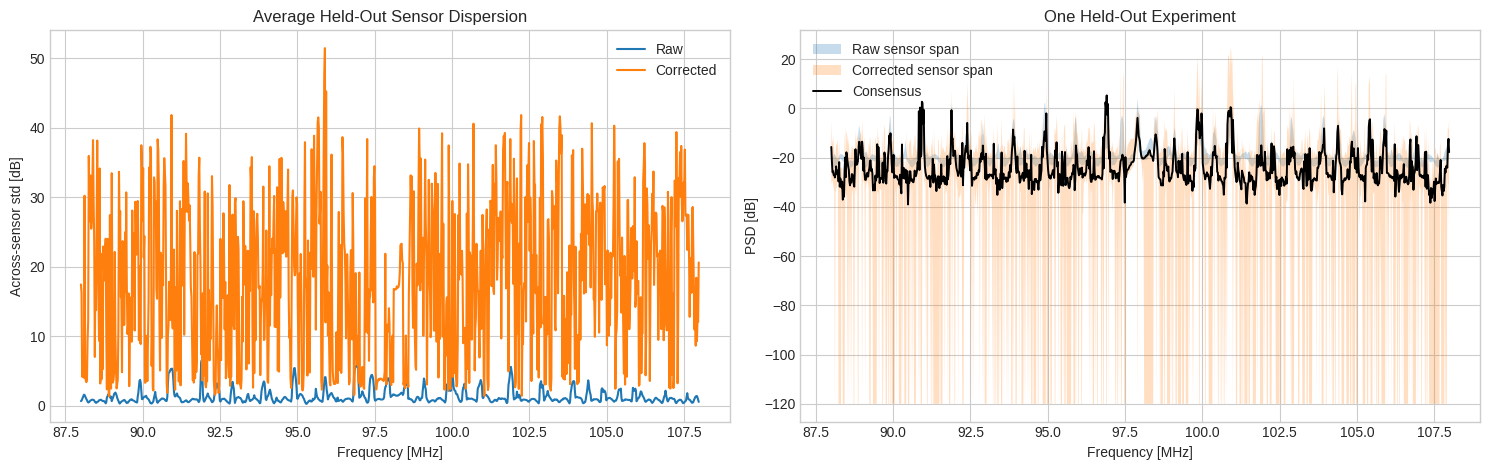

In [15]:
mean_raw_dispersion_profile_db = np.mean(raw_dispersion_db, axis=0)
mean_corrected_dispersion_profile_db = np.mean(corrected_dispersion_db, axis=0)
held_out_experiment = 0

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
axes[0].plot(freq_mhz, mean_raw_dispersion_profile_db[::plot_stride], label="Raw")
axes[0].plot(
    freq_mhz, mean_corrected_dispersion_profile_db[::plot_stride], label="Corrected"
)
axes[0].set_title("Average Held-Out Sensor Dispersion")
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Across-sensor std [dB]")
axes[0].legend()

axes[1].fill_between(
    freq_mhz,
    np.min(raw_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    np.max(raw_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    alpha=0.25,
    label="Raw sensor span",
)
axes[1].fill_between(
    freq_mhz,
    np.min(corrected_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    np.max(corrected_test_db[:, held_out_experiment, :], axis=0)[::plot_stride],
    alpha=0.25,
    label="Corrected sensor span",
)
axes[1].plot(
    freq_mhz,
    consensus_test_db[held_out_experiment, ::plot_stride],
    color="black",
    linewidth=1.4,
    label="Consensus",
)
axes[1].set_title("One Held-Out Experiment")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].set_ylabel("PSD [dB]")
axes[1].legend()
plt.tight_layout()

## Deployment Interpretation

Once the gain and additive-noise curves have been estimated, any new sensor PSD can be transferred to the common network scale with

`S_hat = max(0, (Y - N) / G)`.

When the deployed sensors are again observing the same field, the corrected spectra can be fused with a variance-weighted consensus. The helper functions below are the same ones used in the validation cells above.

In [16]:
deployment_example = {
    "gain_shape": result.gain_power.shape,
    "noise_shape": result.additive_noise_power.shape,
    "consensus_shape": consensus_test_power.shape,
    "first_test_timestamp_ms": int(
        dataset.experiment_timestamps_ms[result.test_indices[0]]
    ),
}
deployment_example

{'gain_shape': (10, 32768),
 'noise_shape': (10, 32768),
 'consensus_shape': (4, 32768),
 'first_test_timestamp_ms': 1771931300515}